## MNIST from Scratch: Neural Networks Without the Magic

The goal is to deeply understand the full mechanics of a neural network without any hidden abstractions.


### PyTorch Implementation

This is the reference implementation.


In [220]:
import torch
import torchvision

In [221]:
# Normalize and load MNIST train/test datasets
transform = torchvision.transforms.Compose(
    [
        torchvision.transforms.ToTensor(),
        torchvision.transforms.Normalize((0.1307,), (0.3081,)),
    ]
)
train_set = torchvision.datasets.MNIST(root="../data", train=True, download=True, transform=transform)
test_set = torchvision.datasets.MNIST(root="../data", train=False, download=True, transform=transform)

print("Number of images in the training dataset:", len(train_set))
print("Number of images in the testing dataset:", len(test_set))

Number of images in the training dataset: 60000
Number of images in the testing dataset: 10000


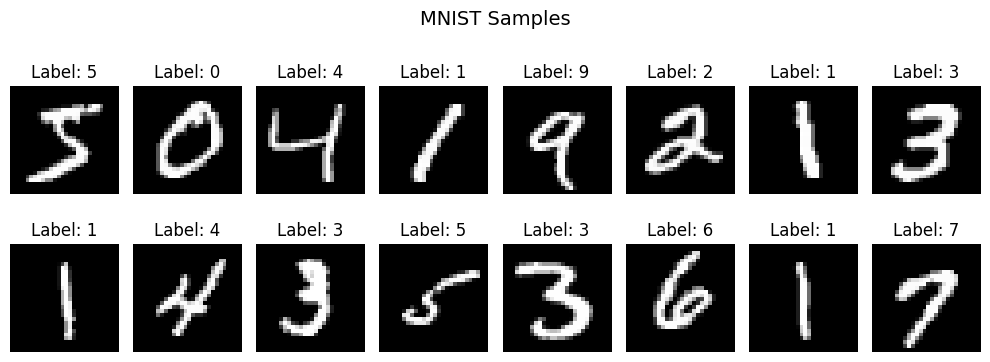

In [222]:
# Visualize the data
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 8, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    img, label = train_set[i]  # Image shape: (1, 28, 28)
    ax.imshow(img.squeeze(), cmap="gray")
    ax.set_title(f"Label: {label}")
    ax.axis("off")

plt.suptitle("MNIST Samples", fontsize=14)
plt.tight_layout()
plt.show()

In [223]:
# Wrap datasets into DataLoaders for mini-batch iterations
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=32, shuffle=False)

In [224]:
# Define the model 
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class BobNet(nn.Module):
    def __init__(self):
        super(BobNet, self).__init__()
        self.l1 = nn.Linear(28 * 28, 128)
        self.l2 = nn.Linear(128, 64)
        self.l3 = nn.Linear(64, 10)
        
    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten the input image
        x = F.relu(self.l1(x))
        x = F.relu(self.l2(x))
        x = F.log_softmax(self.l3(x), dim=1)  
        return x

In [225]:
# Initialize the model
model = BobNet()
print(model)

BobNet(
  (l1): Linear(in_features=784, out_features=128, bias=True)
  (l2): Linear(in_features=128, out_features=64, bias=True)
  (l3): Linear(in_features=64, out_features=10, bias=True)
)
